# Handwritten Digit Classification using ANN (Multi-class)

This notebook builds an Artificial Neural Network using **TensorFlow / Keras** to classify **handwritten digits (0-9)** from the famous **MNIST** dataset.

**Dataset**: MNIST - 70,000 grayscale images of handwritten digits (60,000 train + 10,000 test). Each image is 28x28 pixels.

**Target**:
- `label` - The digit shown in the image (0 through 9) -> 10 classes

**Features**:
- 784 pixel intensities (28 x 28 flattened) with values in [0, 255]

**Pipeline**:
- Load MNIST directly from Keras
- Visualize sample digits & class distribution
- Flatten 28x28 -> 784 and normalize pixels to [0, 1]
- `Dense` + `BatchNormalization` + `Dropout` layers
- `softmax` output + `sparse_categorical_crossentropy` loss (works directly with integer labels)
- `EarlyStopping` callback
- Evaluate with accuracy, classification report and confusion matrix

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style('whitegrid')

ModuleNotFoundError: No module named 'tensorflow'

## 2. Load the Dataset

Keras ships MNIST as a ready-to-use download. It returns NumPy arrays split into train and test.

In [7]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train shape :", X_train.shape)
print("y_train shape :", y_train.shape)
print("X_test  shape :", X_test.shape)
print("y_test  shape :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 61s 5us/step
X_train shape : (60000, 28, 28)
y_train shape : (60000,)
X_test  shape : (10000, 28, 28)
y_test  shape : (10000,)


In [8]:
print("Image dtype   :", X_train.dtype)
print("Pixel min/max :", X_train.min(), "/", X_train.max())
print("Unique labels :", np.unique(y_train))

Image dtype   : uint8
Pixel min/max : 0 / 255
Unique labels : [0 1 2 3 4 5 6 7 8 9]


## 3. Exploratory Data Analysis

### 3.1 Visualize Sample Digits

Display the first 10 training images with their labels to get a feel for the data.

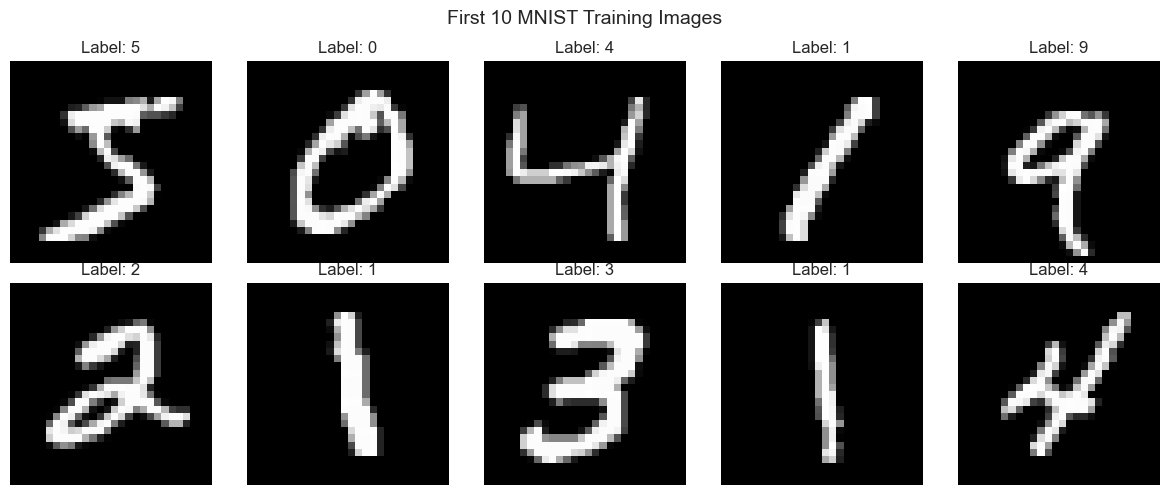

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}", fontsize=12)
    ax.axis('off')

plt.suptitle("First 10 MNIST Training Images", fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Class Distribution

Are the 10 digit classes balanced in the training set?

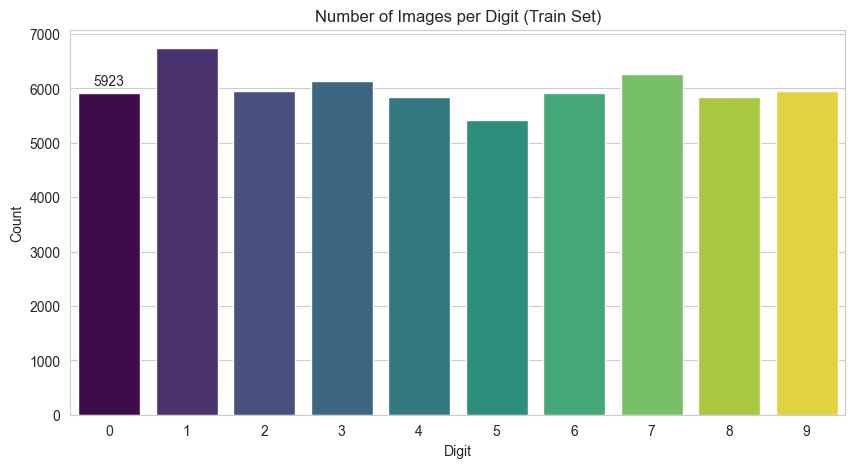

Class distribution (%):
0     9.87
1    11.24
2     9.93
3    10.22
4     9.74
5     9.04
6     9.86
7    10.44
8     9.75
9     9.92
Name: count, dtype: float64


In [10]:
class_counts = pd.Series(y_train).value_counts().sort_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Number of Images per Digit (Train Set)')
plt.xlabel('Digit')
plt.ylabel('Count')
ax.bar_label(ax.containers[0], padding=3)
plt.show()

print("Class distribution (%):")
print((class_counts / class_counts.sum() * 100).round(2))

`All 10 digits are fairly balanced, so we don't need to worry about class imbalance.`

### 3.3 Pixel Intensity Distribution

Most pixels in MNIST are black (0). Only the digit strokes are bright. This will guide our normalization step.

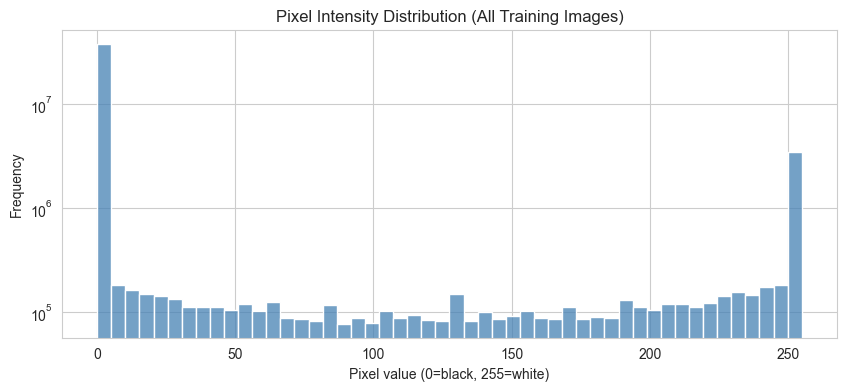

In [11]:
plt.figure(figsize=(10, 4))
sns.histplot(X_train.flatten(), bins=50, color='steelblue')
plt.title('Pixel Intensity Distribution (All Training Images)')
plt.xlabel('Pixel value (0=black, 255=white)')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

## 4. Data Preprocessing

Two things to do before feeding the data to the ANN:
1. **Flatten** each 28x28 image into a 784-length vector (a Dense network expects 1-D input).
2. **Normalize** pixel values from [0, 255] to [0, 1] so gradients behave nicely.

Labels are already integers (0-9) - we'll keep them as-is and use `sparse_categorical_crossentropy` as the loss.

### 4.1 Flatten & Normalize

In [12]:
n_features = 28 * 28  # 784
n_classes  = 10

X_train_flat = X_train.reshape(-1, n_features).astype('float32') / 255.0
X_test_flat  = X_test.reshape(-1, n_features).astype('float32')  / 255.0

print("X_train_flat shape :", X_train_flat.shape)
print("X_test_flat  shape :", X_test_flat.shape)
print("New pixel range    :", X_train_flat.min(), "to", X_train_flat.max())

X_train_flat shape : (60000, 784)
X_test_flat  shape : (10000, 784)
New pixel range    : 0.0 to 1.0


## 5. Build the ANN

A 3-hidden-layer fully connected network (256 -> 128 -> 64) with `BatchNormalization` and `Dropout` for regularization. The output layer has 10 neurons with `softmax` activation - one probability per digit class.

In [13]:
model = Sequential()

# Input layer
model.add(Input(shape=(n_features,)))

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Output layer - 10 classes
model.add(Dense(n_classes, activation='softmax'))

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

## 6. Train the Model

`EarlyStopping` halts training once the validation loss stops improving and restores the best weights. We hold out 10% of the training data as a validation set.

In [14]:
early_stop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    verbose=1,
    mode="min",
    restore_best_weights=True
)

history = model.fit(
    X_train_flat, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7669 - loss: 0.7530 - val_accuracy: 0.9637 - val_loss: 0.1207
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9413 - loss: 0.1983 - val_accuracy: 0.9677 - val_loss: 0.0991
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9530 - loss: 0.1497 - val_accuracy: 0.9780 - val_loss: 0.0747
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9623 - loss: 0.1219 - val_accuracy: 0.9757 - val_loss: 0.0797
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9672 - loss: 0.1105 - val_accuracy: 0.9803 - val_loss: 0.0663
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9691 - loss: 0.1003 - val_accuracy: 0.9800 - val_loss: 0.0695
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9719 - loss: 0.0894 - val_accuracy: 0.9787 - val_loss: 0.0702
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9749 - loss: 0.0777 - val_accuracy: 0.

## 7. Training History

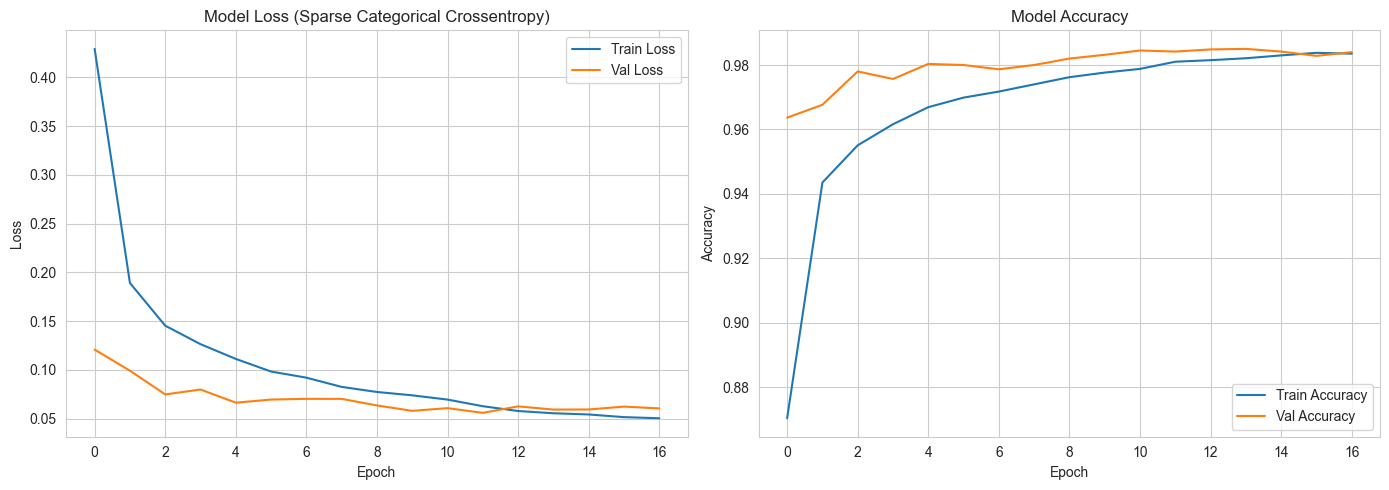

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss (Sparse Categorical Crossentropy)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Evaluate on Test Set

### 8.1 Overall Accuracy & Loss

In [16]:
test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

Test Loss     : 0.0644
Test Accuracy : 0.9801


### 8.2 Predict on Test Set

In [17]:
y_pred_proba = model.predict(X_test_flat, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

for actual, pred in zip(y_test[10:20], y_pred[10:20]):
    mark = 'OK' if actual == pred else 'X'
    print(f"Actual: {actual}   Predicted: {pred}   [{mark}]")

Actual: 0   Predicted: 0   [OK]
Actual: 6   Predicted: 6   [OK]
Actual: 9   Predicted: 9   [OK]
Actual: 0   Predicted: 0   [OK]
Actual: 1   Predicted: 1   [OK]
Actual: 5   Predicted: 5   [OK]
Actual: 9   Predicted: 9   [OK]
Actual: 7   Predicted: 7   [OK]
Actual: 3   Predicted: 3   [OK]
Actual: 4   Predicted: 4   [OK]


### 8.3 Classification Report

Per-class precision, recall and F1-score.

In [18]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9848    0.9898    0.9873       980
           1     0.9921    0.9938    0.9930      1135
           2     0.9854    0.9797    0.9825      1032
           3     0.9679    0.9851    0.9764      1010
           4     0.9776    0.9796    0.9786       982
           5     0.9874    0.9675    0.9773       892
           6     0.9742    0.9864    0.9803       958
           7     0.9712    0.9825    0.9768      1028
           8     0.9853    0.9630    0.9740       974
           9     0.9751    0.9703    0.9727      1009

    accuracy                         0.9801     10000
   macro avg     0.9801    0.9798    0.9799     10000
weighted avg     0.9802    0.9801    0.9801     10000



### 8.4 Confusion Matrix

Rows = true digit, columns = predicted digit. Diagonal = correct predictions; off-diagonal cells show the most common mistakes (e.g. 4 vs 9, 3 vs 5).

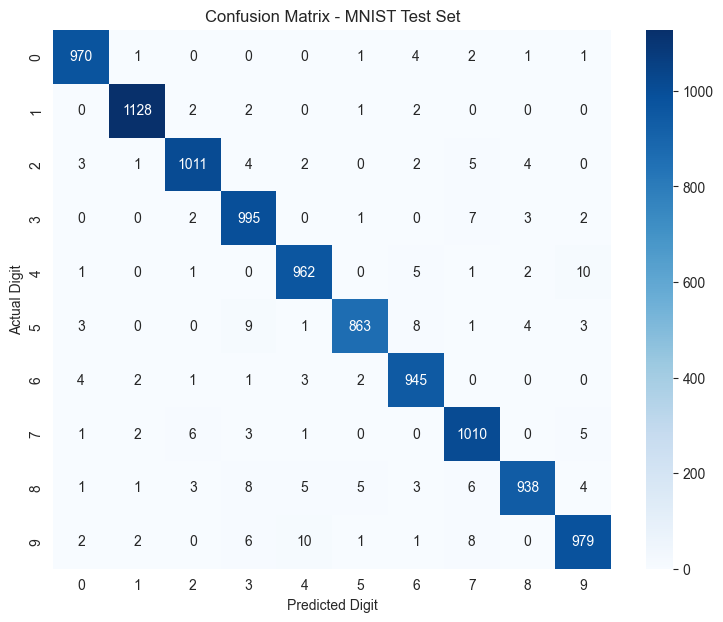

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10),
    cbar=True
)
plt.title('Confusion Matrix - MNIST Test Set')
plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')
plt.show()

## 9. Inference on a Single Image

Helper that takes any 28x28 image, applies the same flatten + normalize pipeline, then returns the predicted digit and the per-class probabilities.

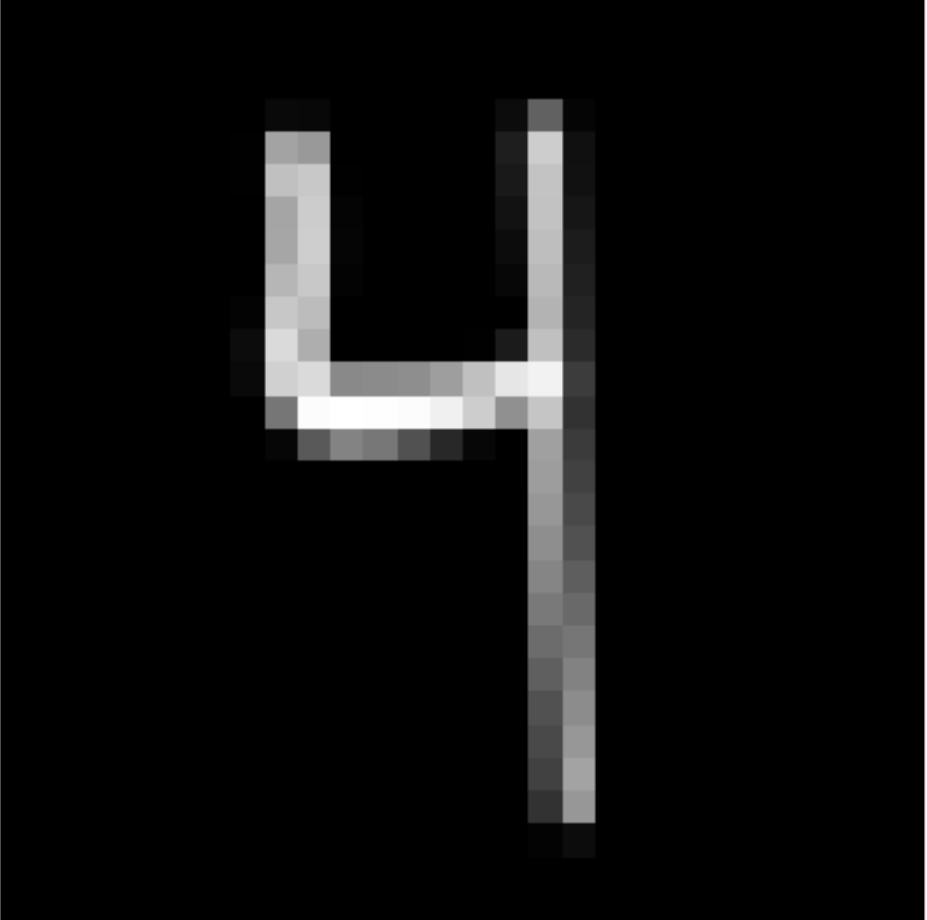

In [20]:
from PIL import Image
img = Image.open("4no.png").convert("L")  # Convert to grayscale
img = img.resize((28, 28)) # Resize to 28x28

# Convert to numpy array
img_array = np.array(img)
img_array = 255 - img_array



FileNotFoundError: [Errno 2] No such file or directory: '4no.png'

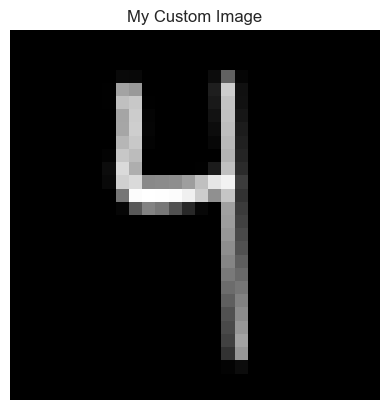

In [23]:
from PIL import Image
img = Image.open("4no.png").convert("L")  # Convert to grayscale
img = img.resize((28, 28)) # Resize to 28x28

# Convert to numpy array
img_array = np.array(img)
img_array = 255 - img_array


# Show image
plt.imshow(img_array, cmap="gray")
plt.title(f"My Custom Image")
plt.axis("off")
plt.show()


In [27]:
def inference(model, img_array):
    # Preprocess the image
    img_flat = img_array.reshape(1, -1).astype('float32') / 255.0

    # Predict
    pred_proba = model.predict(img_flat, verbose=0)
    print(f"Predicted probabilities: {pred_proba}\n")
    pred_class = np.argmax(pred_proba, axis=1)[0]
    print(f"Predicted class: {pred_class}\n")
    pred_confidence = np.max(pred_proba)
    print(f"Prediction confidence: {pred_confidence}\n")


In [28]:
inference(model, img_array)

Predicted probabilities: [[4.9681084e-06 9.3330098e-05 1.5410948e-05 7.9513542e-05 9.9841952e-01
  1.4567038e-04 1.6673634e-05 3.8728691e-04 4.9210026e-05 7.8842737e-04]]

Predicted class: 4

Prediction confidence: 0.9984195232391357

